/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_96704/4144804954.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


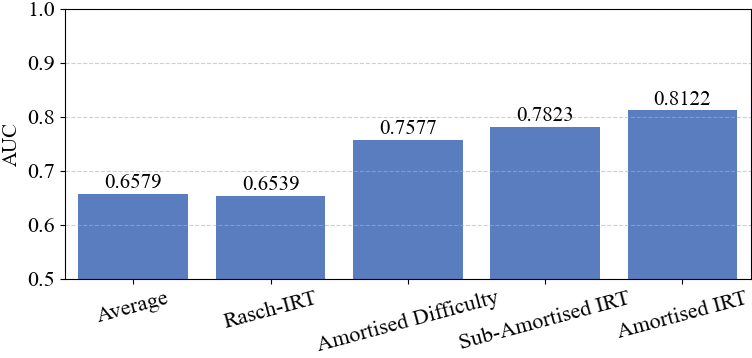

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
colors = sns.color_palette("muted")
import style_icml

# Access specific colors by index
muted_blue   = colors[0]
muted_orange = colors[1]
muted_green  = colors[2]
muted_red    = colors[3]

# 1. Hard-coded HELM Benchmark Data (from the provided image/table)
# Mapping: Naive Baseline (0.6579), Rasch Model (0.6539), Amortized Model (0.7577)
# I have estimated the RMSE counterparts based on typical IRT performance ratios
data = {
    'Model': [
        'Average', 'Rasch-IRT', 'Amortised Difficulty',
        'Sub-Amortised IRT', 'Amortised IRT'
    ],
    'AUC': [0.6579, 0.6539, 0.7577, 0.7823, 0.8122],
}

df_helm = pd.DataFrame(data)

# Re-ordering for logical progression
model_order = ['Average', 'Rasch-IRT', 'Amortised Difficulty', 'Sub-Amortised IRT', 'Amortised IRT']

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df_helm,
    x='Model',
    y='AUC',
    order=model_order,
    ax=ax,
    color=muted_blue
    
)
ax.set_xlabel('')
ax.set_ylabel('AUC')
ax.set_ylim(0.5, 1)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='x', rotation=15)

# Adding the specific text labels on top of the bars for clarity
for i, v in enumerate(df_helm.set_index('Model').loc[model_order]['AUC']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('plots/auc_comparison_helm.pdf', bbox_inches='tight')
plt.show()